In [ ]:
## Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective
##Analyze the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data and the Fear & Greed Index.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [5]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [6]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [7]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [8]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [12]:
trades[['Timestamp IST', 'Timestamp']].head()

,Timestamp IST,Timestamp
0,02-12-2024 22:50,1.730000e+12
1,02-12-2024 22:50,1.730000e+12
2,02-12-2024 22:50,1.730000e+12
3,02-12-2024 22:50,1.730000e+12
4,02-12-2024 22:50,1.730000e+12


In [13]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date

In [14]:
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [15]:
print(trades['date'].dtype)

object


In [16]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [17]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [18]:
print(sentiment['date'].dtype)

object


In [19]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [20]:
print("Merged Shape:", merged.shape)

Merged Shape: (211224, 18)


In [21]:
merged[['date', 'Closed PnL', 'classification']].head()

,date,Closed PnL,classification
0,2024-12-02,0.0,Extreme Greed
1,2024-12-02,0.0,Extreme Greed
2,2024-12-02,0.0,Extreme Greed
3,2024-12-02,0.0,Extreme Greed
4,2024-12-02,0.0,Extreme Greed


In [22]:
merged['classification'].isnull().sum()

np.int64(6)

In [23]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [24]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [25]:
merged.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

,Closed PnL
classification,
Fear,3.357155e+06
Extreme Greed,2.715171e+06
Greed,2.150129e+06
Neutral,1.292921e+06
Extreme Fear,7.391102e+05


In [26]:
merged['win'] = (merged['Closed PnL'] > 0).astype(int)

In [27]:
merged.groupby('classification')['win'].mean() * 100

,win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


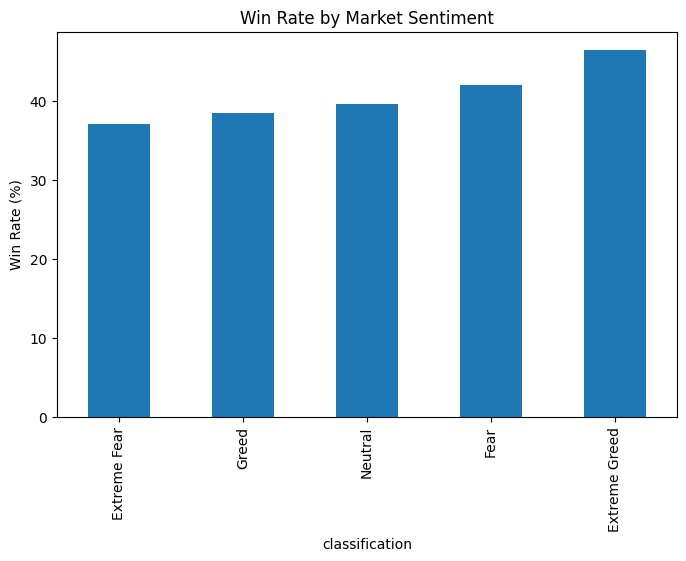

In [28]:
plt.figure(figsize=(8,5))

(merged.groupby('classification')['win']
 .mean()
 .sort_values()
 * 100).plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()

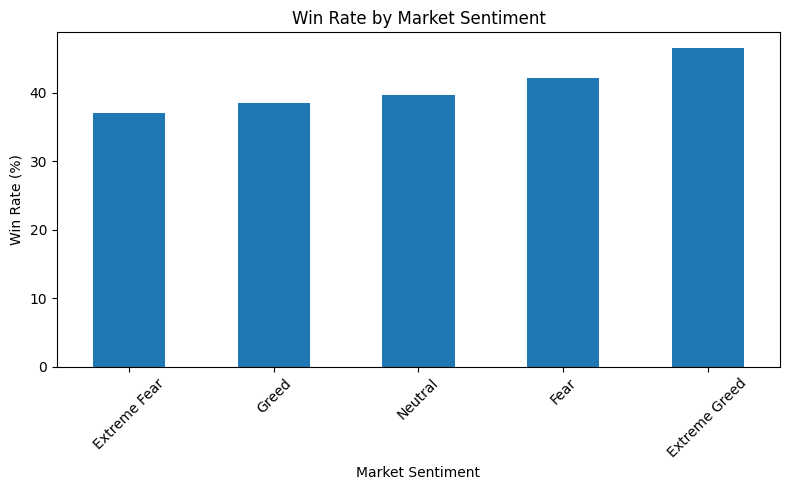

In [29]:
plt.figure(figsize=(8,5))

win_rate = merged.groupby('classification')['win'].mean() * 100

win_rate = win_rate.sort_values()

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [30]:
merged.groupby('classification')['Size USD'].agg(
    ['count', 'mean', 'sum']
).sort_values('sum', ascending=False)

,count,mean,sum
classification,,,
Fear,61837,7816.109931,4.833248e+08
Greed,50303,5736.884375,2.885825e+08
Neutral,37686,4782.732661,1.802421e+08
Extreme Greed,39992,3112.251565,1.244652e+08
Extreme Fear,21400,5349.731843,1.144843e+08


In [31]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

top_traders.head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


In [32]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

top_traders.head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


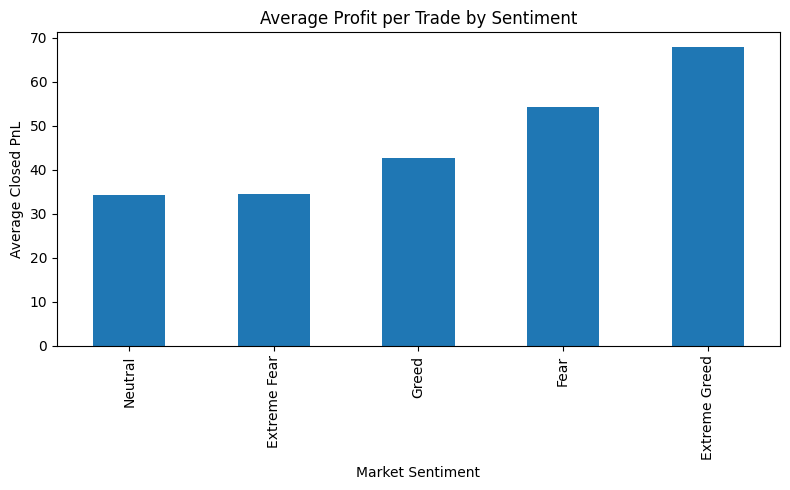

In [33]:
plt.figure(figsize=(8,5))

merged.groupby('classification')['Closed PnL']\
      .mean()\
      .sort_values()\
      .plot(kind='bar')

plt.title('Average Profit per Trade by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

plt.tight_layout()
plt.show()

In [34]:
summary = merged.groupby('classification').agg(
    trades=('Closed PnL','count'),
    avg_pnl=('Closed PnL','mean'),
    total_pnl=('Closed PnL','sum'),
    win_rate=('win','mean'),
    avg_trade_size=('Size USD','mean')
)

summary['win_rate'] = summary['win_rate'] * 100

summary.round(2)

,trades,avg_pnl,total_pnl,win_rate,avg_trade_size
classification,,,,,
Extreme Fear,21400,34.54,739110.25,37.06,5349.73
Extreme Greed,39992,67.89,2715171.31,46.49,3112.25
Fear,61837,54.29,3357155.44,42.08,7816.11
Greed,50303,42.74,2150129.27,38.48,5736.88
Neutral,37686,34.31,1292920.68,39.70,4782.73


In [35]:
merged.groupby('Direction')['Closed PnL'].agg(
    ['count','mean','sum']
).round(2)

,count,mean,sum
Direction,,,
Auto-Deleveraging,8,7184.81,57478.46
Buy,16716,0.00,0.00
Close Long,48678,74.43,3622929.39
Close Short,36013,103.01,3709800.10
Liquidated Isolated Short,1,-12752.91,-12752.91
Long > Short,57,34.94,1991.38
Open Long,49895,0.00,0.00
Open Short,39741,0.00,0.00
Sell,19902,146.05,2906748.42


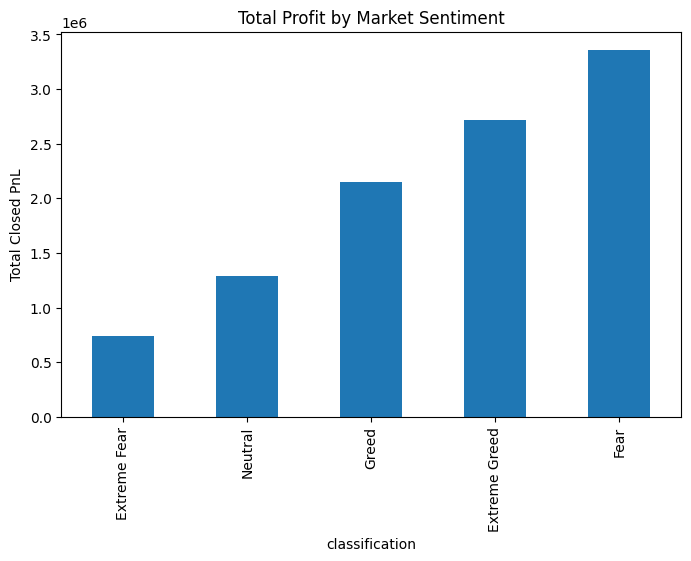

In [36]:
plt.figure(figsize=(8,5))

merged.groupby('classification')['Closed PnL']\
      .sum()\
      .sort_values()\
      .plot(kind='bar')

plt.title('Total Profit by Market Sentiment')
plt.ylabel('Total Closed PnL')
plt.show()

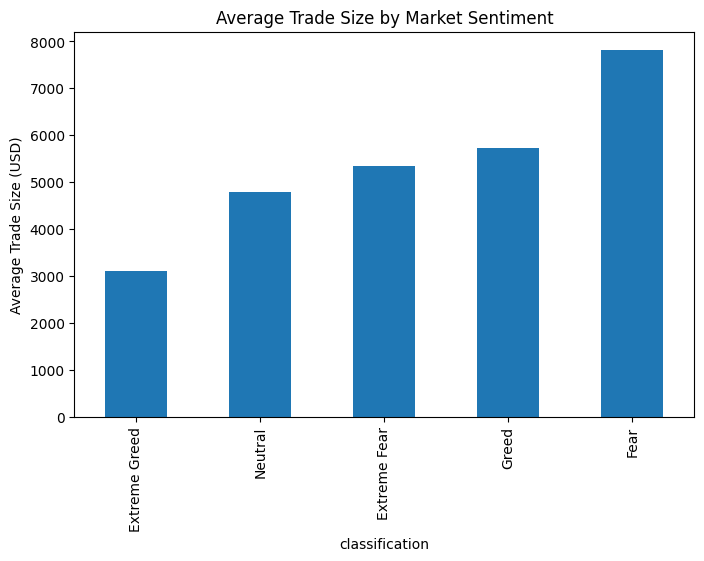

In [37]:
plt.figure(figsize=(8,5))

merged.groupby('classification')['Size USD']\
      .mean()\
      .sort_values()\
      .plot(kind='bar')

plt.title('Average Trade Size by Market Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.show()